# Compare XAI From Scratch vs Baseline

Notebook nay doc truc tiep ket qua trong `output/xai_from_scratch` va `output/train_baseline` de:
- tom tat metric quan trong cua 2 run
- so sanh training curves theo epoch
- xem them saliency metrics cua XAI
- hien thi mot so artifact anh tu baseline neu co


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

ROOT = Path.cwd()
if not (ROOT / "output").exists():
    candidates = [p for p in ROOT.parents if (p / "output").exists()]
    if candidates:
        ROOT = candidates[0]

XAI_DIR = ROOT / "output" / "xai_from_scratch"
BASELINE_DIR = ROOT / "output" / "train_baseline" / "outputs" / "yolo" / "baseline"

print(f"ROOT: {ROOT}")
print(f"XAI_DIR exists: {XAI_DIR.exists()} -> {XAI_DIR}")
print(f"BASELINE_DIR exists: {BASELINE_DIR.exists()} -> {BASELINE_DIR}")

ROOT: /home/thanhmay/workspace/xai-driven-saliency-loss
XAI_DIR exists: True -> /home/thanhmay/workspace/xai-driven-saliency-loss/output/xai_from_scratch
BASELINE_DIR exists: True -> /home/thanhmay/workspace/xai-driven-saliency-loss/output/train_baseline/outputs/yolo/baseline


In [2]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


xai_history = pd.read_csv(XAI_DIR / "weights" / "train_history.csv")
xai_summary = load_json(XAI_DIR / "summary" / "run_summary.json")
xai_best_val = load_json(XAI_DIR / "metrics" / "best_val_metrics.json")
xai_best_test = load_json(XAI_DIR / "metrics" / "best_test_metrics.json")

baseline_history = pd.read_csv(BASELINE_DIR / "results.csv")
baseline_history.columns = [c.strip() for c in baseline_history.columns]
baseline_best_idx = baseline_history["metrics/mAP50-95(B)"].idxmax()
baseline_best = baseline_history.loc[baseline_best_idx].copy()
baseline_final = baseline_history.iloc[-1].copy()

print("XAI history shape:", xai_history.shape)
print("Baseline history shape:", baseline_history.shape)
display(xai_history.head(2))
display(baseline_history.head(2))

XAI history shape: (55, 17)
Baseline history shape: (67, 20)


,epoch,num_batches,lr,lambda_saliency,train_detection_loss,train_saliency_loss,train_total_loss,train_energy_in_box,train_pointing_game,train_saliency_iou,val_precision,val_recall,val_map50,val_map50_95,val_fitness,val_results_dir,epoch_seconds
0,1,451,0.0001,0.00000,99.951284,0.988684,99.951284,0.011316,0.026851,0.011534,0.430145,0.458772,0.406322,0.200871,0.200871,/kaggle/working/runs/detect/val-3,206.115654
1,2,451,0.0001,0.00025,85.154226,0.988616,85.154471,0.011384,0.033017,0.014271,0.531160,0.473055,0.461359,0.220796,0.220796,/kaggle/working/runs/detect/val-4,200.149459


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,161.278,2.05998,4.06543,1.90606,0.27125,0.25182,0.15656,0.06550,2.10027,2.96063,2.05732,0.009978,0.003326,0.009978,0.003326,0.009978,0.003326,0.009978,0.003326
1,2,274.566,1.92081,2.82932,1.74372,0.30006,0.34246,0.25530,0.10191,2.03874,2.60219,1.89960,0.019780,0.006593,0.019780,0.006593,0.019780,0.006593,0.019780,0.006593


In [3]:
summary_rows = [
    {
        "run": "baseline",
        "epochs_completed": int(baseline_final["epoch"]),
        "best_epoch": int(baseline_best["epoch"]),
        "best_precision": float(baseline_best["metrics/precision(B)"]),
        "best_recall": float(baseline_best["metrics/recall(B)"]),
        "best_map50": float(baseline_best["metrics/mAP50(B)"]),
        "best_map50_95": float(baseline_best["metrics/mAP50-95(B)"]),
        "final_precision": float(baseline_final["metrics/precision(B)"]),
        "final_recall": float(baseline_final["metrics/recall(B)"]),
        "final_map50": float(baseline_final["metrics/mAP50(B)"]),
        "final_map50_95": float(baseline_final["metrics/mAP50-95(B)"]),
    },
    {
        "run": "xai_from_scratch",
        "epochs_completed": int(xai_summary["num_epochs_completed"]),
        "best_epoch": int(xai_summary["best_epoch"]),
        "best_precision": float(xai_best_val["precision"]),
        "best_recall": float(xai_best_val["recall"]),
        "best_map50": float(xai_best_val["map50"]),
        "best_map50_95": float(xai_best_val["map50_95"]),
        "final_precision": float(xai_history.iloc[-1]["val_precision"]),
        "final_recall": float(xai_history.iloc[-1]["val_recall"]),
        "final_map50": float(xai_history.iloc[-1]["val_map50"]),
        "final_map50_95": float(xai_history.iloc[-1]["val_map50_95"]),
    },
]

summary_df = pd.DataFrame(summary_rows).set_index("run")
delta_df = (summary_df.loc["xai_from_scratch"] - summary_df.loc["baseline"]).to_frame("xai_minus_baseline")

display(Markdown("## Bang tong hop"))
display(summary_df.round(4))
display(Markdown("## Chenh lech XAI - Baseline"))
display(delta_df.round(4))

## Bang tong hop

,epochs_completed,best_epoch,best_precision,best_recall,best_map50,best_map50_95,final_precision,final_recall,final_map50,final_map50_95
run,,,,,,,,,,
baseline,67,47,0.7254,0.6920,0.7437,0.3934,0.7304,0.6749,0.7271,0.3862
xai_from_scratch,55,35,0.7196,0.6988,0.7233,0.3801,0.7518,0.6588,0.7126,0.3652


## Chenh lech XAI - Baseline

,xai_minus_baseline
epochs_completed,-12.0000
best_epoch,-12.0000
best_precision,-0.0058
best_recall,0.0069
best_map50,-0.0204
best_map50_95,-0.0134
final_precision,0.0215
final_recall,-0.0161
final_map50,-0.0145
final_map50_95,-0.0210


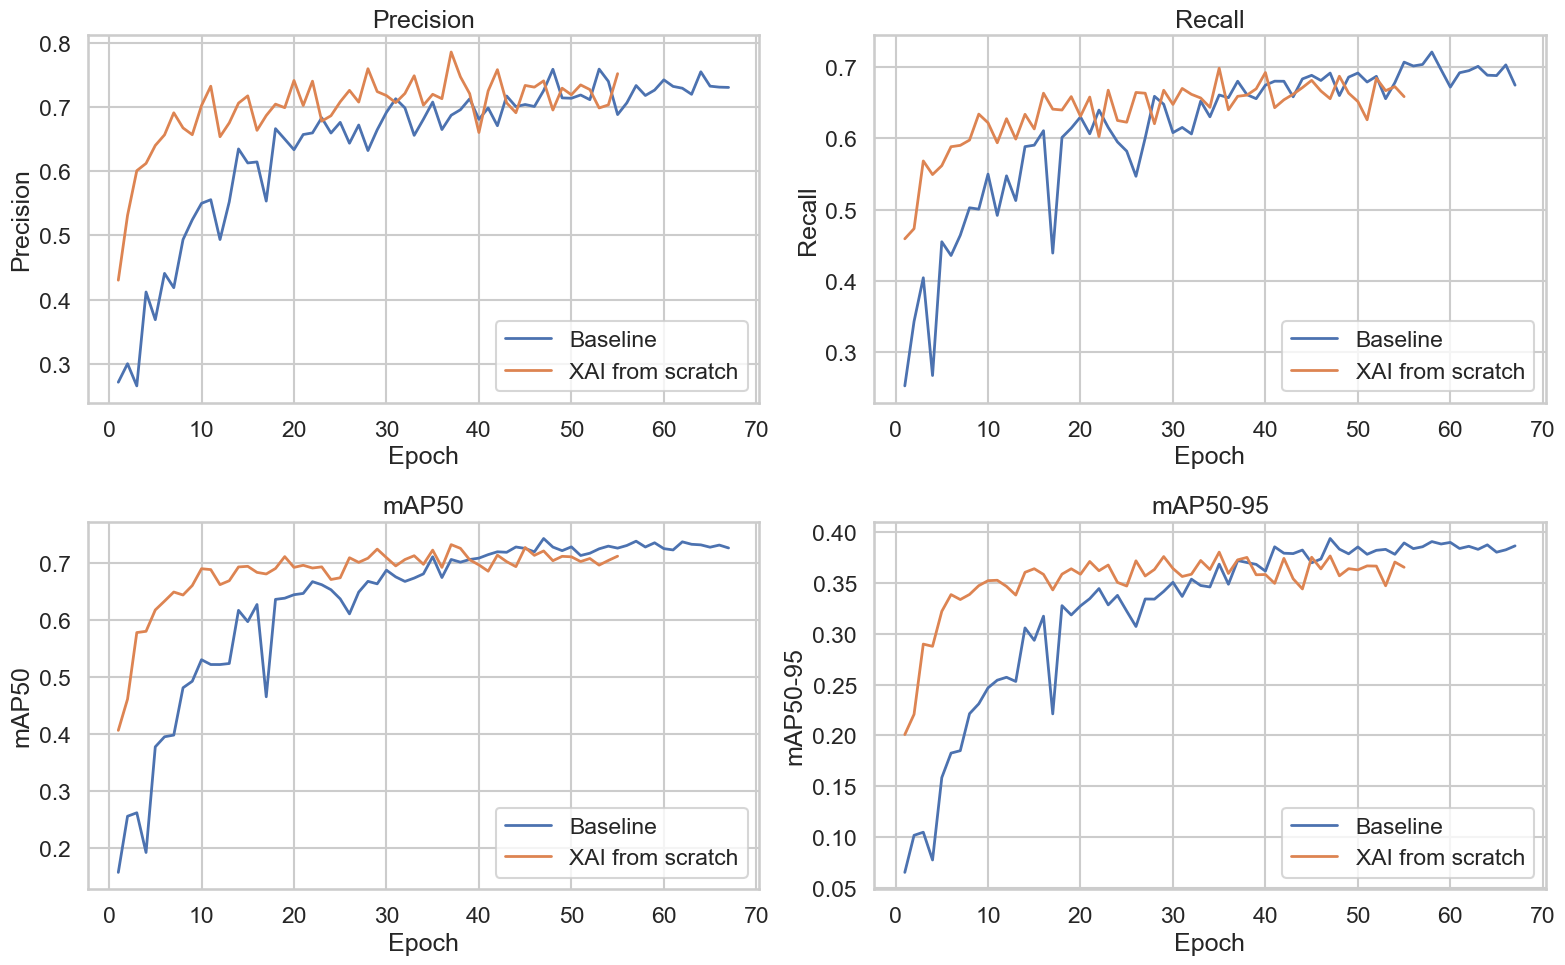

In [4]:
metric_pairs = [
    ("metrics/precision(B)", "val_precision", "Precision"),
    ("metrics/recall(B)", "val_recall", "Recall"),
    ("metrics/mAP50(B)", "val_map50", "mAP50"),
    ("metrics/mAP50-95(B)", "val_map50_95", "mAP50-95"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten()

for ax, (baseline_col, xai_col, title) in zip(axes, metric_pairs):
    ax.plot(baseline_history["epoch"], baseline_history[baseline_col], label="Baseline", linewidth=2)
    ax.plot(xai_history["epoch"], xai_history[xai_col], label="XAI from scratch", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.show()

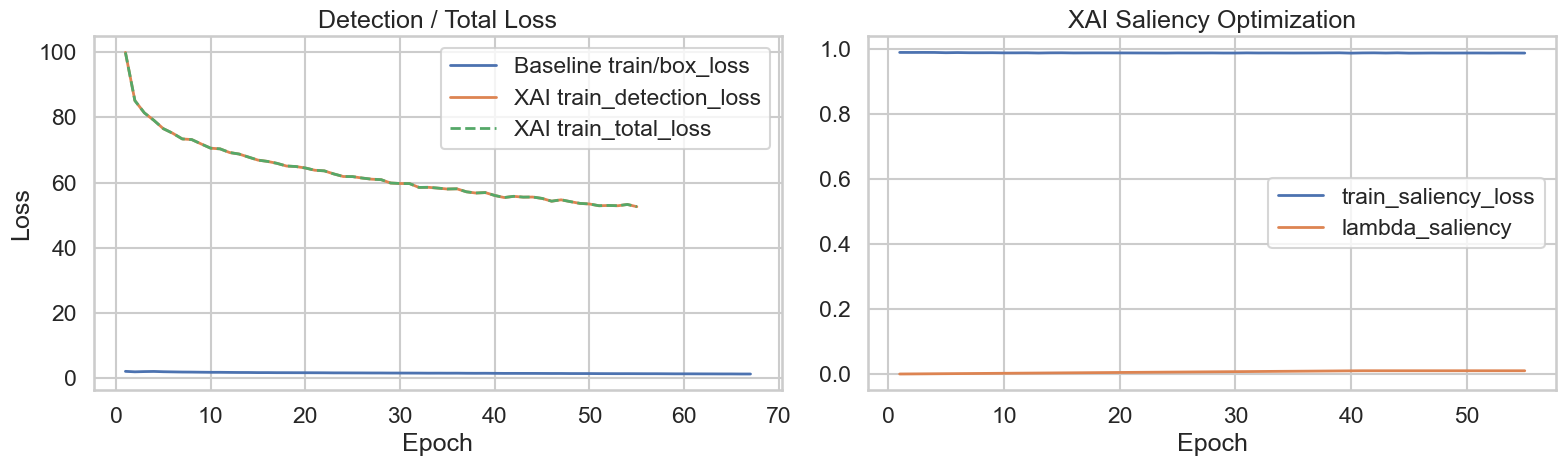

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(baseline_history["epoch"], baseline_history["train/box_loss"], label="Baseline train/box_loss", linewidth=2)
axes[0].plot(xai_history["epoch"], xai_history["train_detection_loss"], label="XAI train_detection_loss", linewidth=2)
axes[0].plot(xai_history["epoch"], xai_history["train_total_loss"], label="XAI train_total_loss", linewidth=2, linestyle="--")
axes[0].set_title("Detection / Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(xai_history["epoch"], xai_history["train_saliency_loss"], label="train_saliency_loss", linewidth=2)
axes[1].plot(xai_history["epoch"], xai_history["lambda_saliency"], label="lambda_saliency", linewidth=2)
axes[1].set_title("XAI Saliency Optimization")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

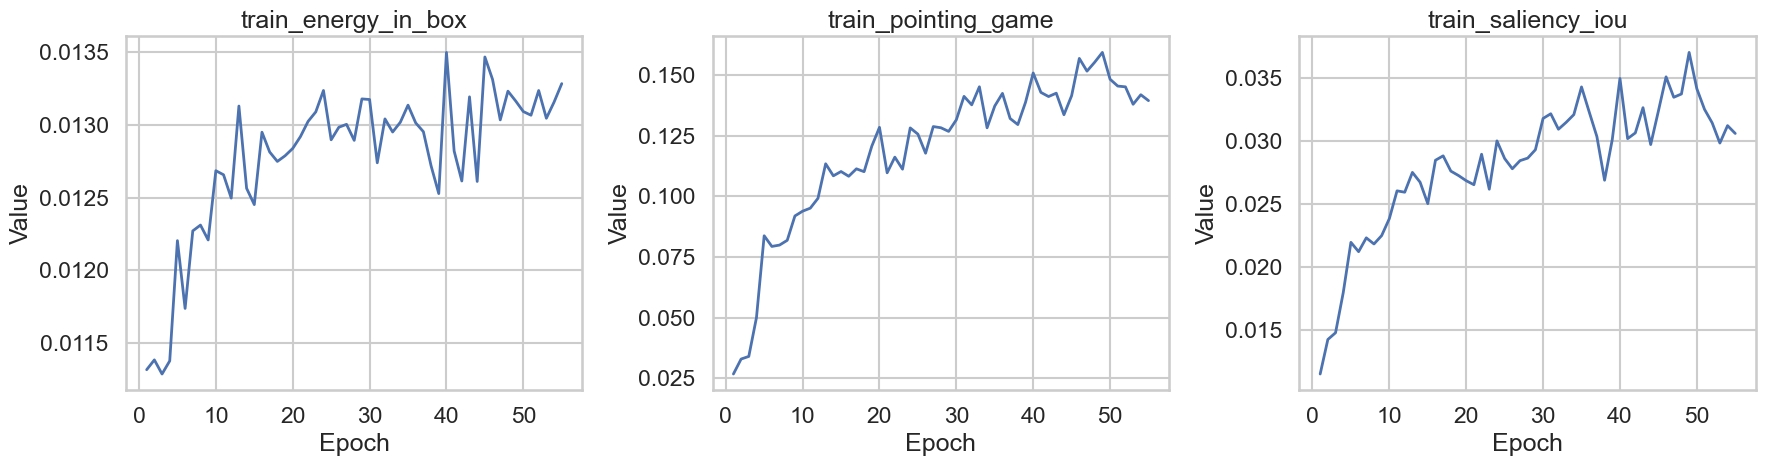

In [6]:
saliency_cols = [
    "train_energy_in_box",
    "train_pointing_game",
    "train_saliency_iou",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
for ax, col in zip(axes, saliency_cols):
    ax.plot(xai_history["epoch"], xai_history[col], linewidth=2)
    ax.set_title(col)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

### overview

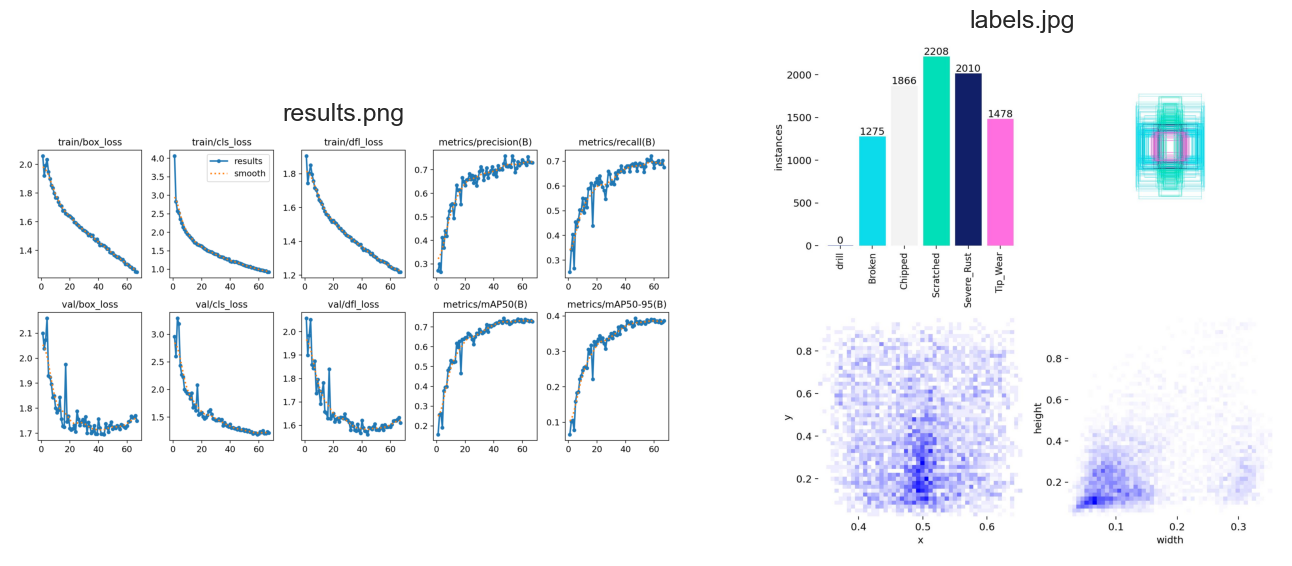

### confusion

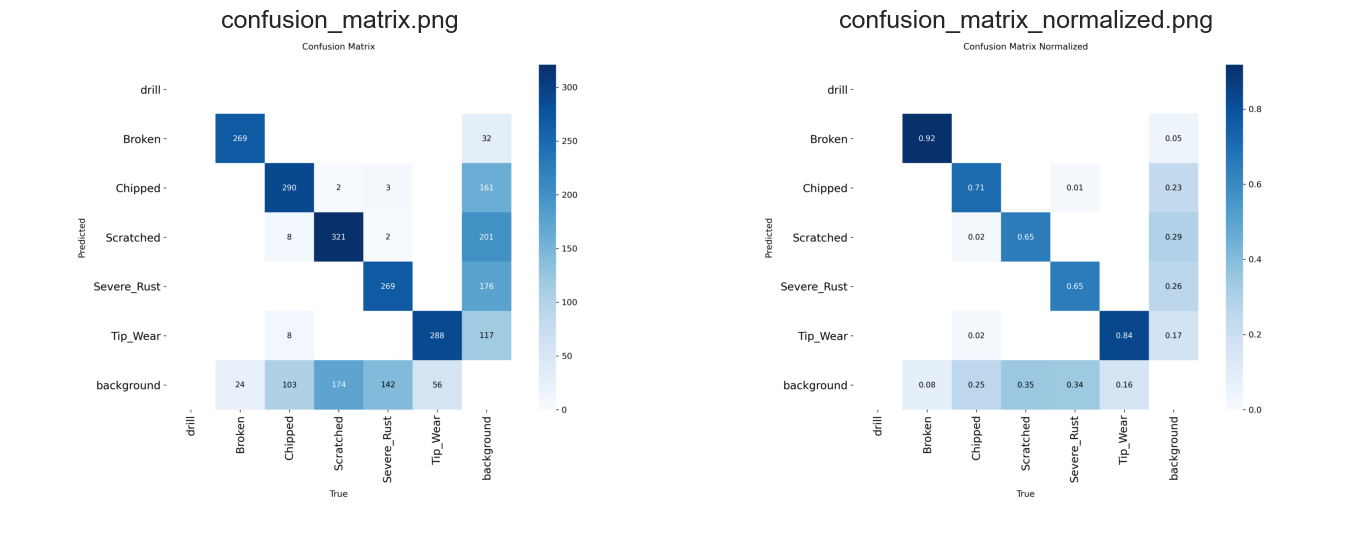

### validation_examples

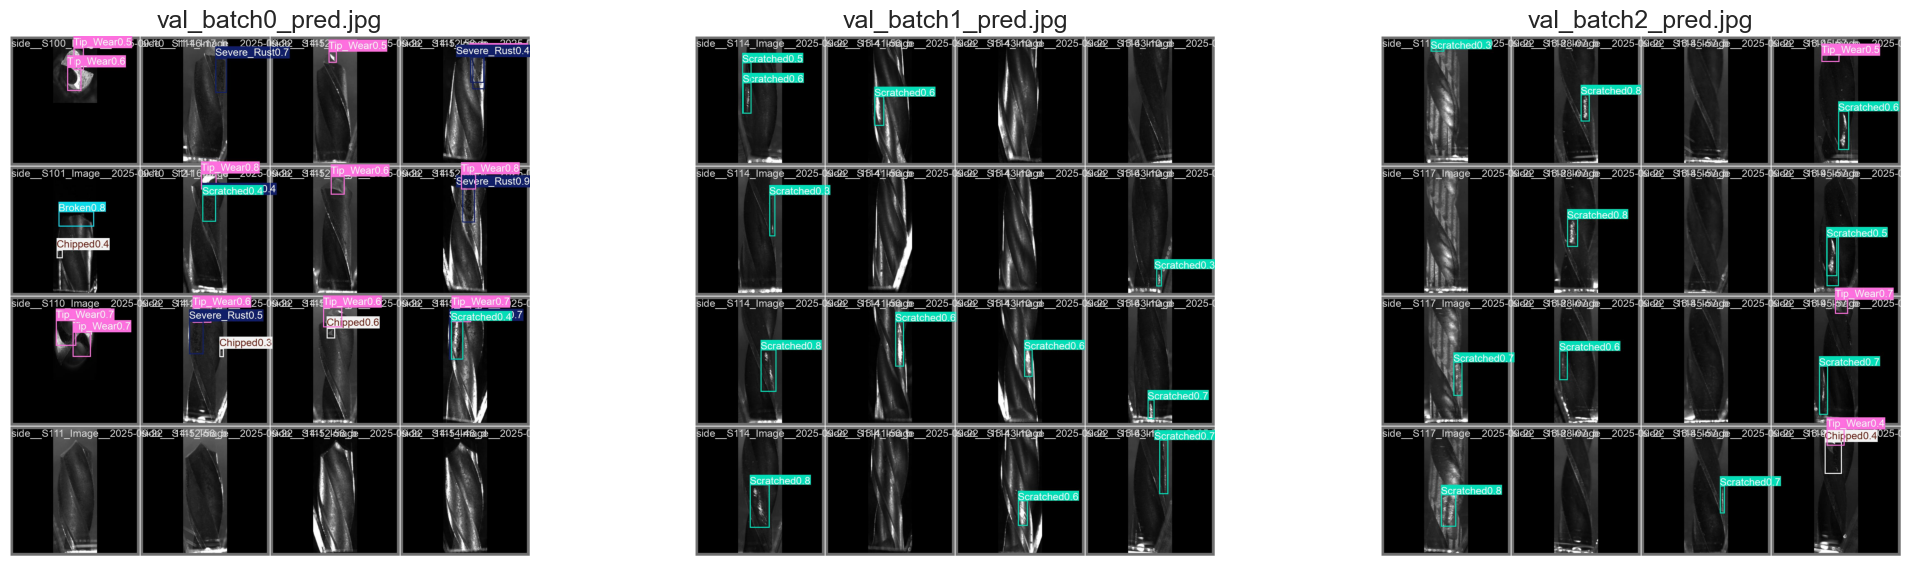

## Ghi chu

Khong tim thay XAI validation artifact tren may hien tai. Duong dan goc trong metadata la: /kaggle/working/runs/detect/val-58


In [7]:
artifact_groups = {
    "overview": [
        BASELINE_DIR / "results.png",
        BASELINE_DIR / "labels.jpg",
    ],
    "confusion": [
        BASELINE_DIR / "confusion_matrix.png",
        BASELINE_DIR / "confusion_matrix_normalized.png",
    ],
    "validation_examples": [
        BASELINE_DIR / "val_batch0_pred.jpg",
        BASELINE_DIR / "val_batch1_pred.jpg",
        BASELINE_DIR / "val_batch2_pred.jpg",
    ],
}

for group_name, paths in artifact_groups.items():
    existing = [p for p in paths if p.exists()]
    if not existing:
        display(Markdown(f"### {group_name}\nKhong tim thay artifact trong nhom nay."))
        continue

    display(Markdown(f"### {group_name}"))
    fig, axes = plt.subplots(1, len(existing), figsize=(7 * len(existing), 6))
    if len(existing) == 1:
        axes = [axes]

    for ax, path in zip(axes, existing):
        ax.imshow(mpimg.imread(path))
        ax.set_title(path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

xai_val_dir = Path(xai_best_val.get("save_dir", ""))
display(Markdown("## Ghi chu"))
if xai_val_dir.exists():
    print(f"XAI validation artifact dir: {xai_val_dir}")
else:
    print(
        "Khong tim thay XAI validation artifact tren may hien tai. "
        f"Duong dan goc trong metadata la: {xai_val_dir}"
    )